In [1]:
pip install torchvision

In [2]:
import torch#This line imports the PyTorch library.Pytorch
#is a deep learning library.
#We need PyTorch because Neural Style Transfer is a deep learning task.

import torch.optim as optim#torch.optim is a special module inside PyTorch.
#It contains optimizers
#An optimizer is an algorithm that improves the result step by step
#In deep learning optimizer reduces errors and improves output

#The optimizer improves:
#The generated image step by step until it looks artistic.
#Imagine:you are drawing a painting
#every time you correct mistakes
#painting becomes better
#Optimizer does the same thing automatically.

from torchvision import models, transforms#Torch vision is a special library
#from Pytorch Library.In this code we will need torch vision to load VGG19
#deep learning model which is trained on millions of images
#we will need it to extract the styles,features etc from the image

#Without torchvision, you would have to manually create
#the entire VGG19 network yourself.
#That would require:
#hundreds of lines of code
#convolution layers
#pooling layers
#activation functions
#It will be Very difficult.

#transforms module is also needed from torchvision to transform the image
#Deep learning models cannot directly understand normal images.
#Images must be converted into proper format.
#CNN models expect fixed-size images.
#If one image is 500×300
#another is 1000×700
#model processing becomes difficult.
#So we resize all images to same size.

#We also need to image into tensor format because PyTorch neural networks only
#understand tensors NOT normal JPG or PNG images.

from PIL import Image#PIL means Python Imaging Library
#PIL is a part of Pillow library of Python
#This line helps us to open and read the image(content and style image)
#so that we can tranform the format,resize the image etc

#Because Neural Style Transfer works on images
#We must:open content image
#open style image
#before sending them to deep learning model

import matplotlib.pyplot as plt#this library is used for plotting graphs
#and displaying images.In this practical it will be used
#to display images

Images Loaded Successfully


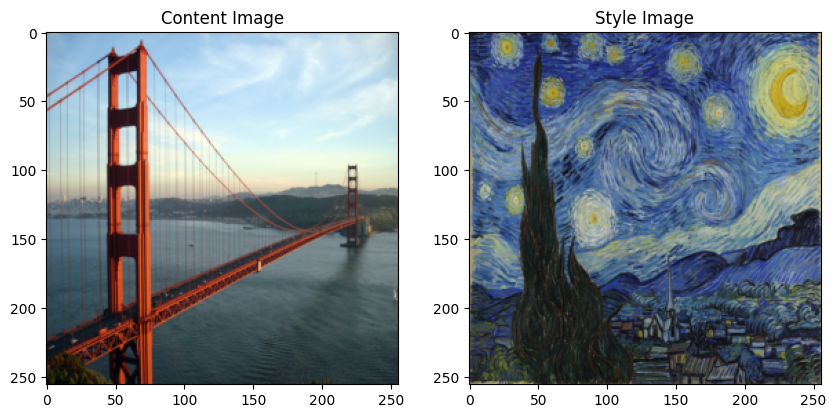

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_image(path, size=256):#we are creating a function to load the  image
    #in the program
    #path stores the image file location
    #size=256 sets the image default size as 256 x256 pixels
    #if size=256 not mentioned then Python automatically sets
    #image size as 256 x 256 pixels

    image = Image.open(path)#This line read,opens and load image file in
    #the memory

    loader = transforms.Compose([
        # Resize image
        transforms.Resize((size, size)),
        # Convert image into tensor
        transforms.ToTensor()
    ])

    image = loader(image).unsqueeze(0)#loader(image) applies the transfromation
    #means here the resizing of the loaded image and transformation
    #to tensor happen
    #After Transformation to tensor the shape will become 3 x 256 x 256 means now it is
    #3 Dimensional image Channel X Height x Width
    #Here 3 represent the 3 color channels means the RGB color channels
    #RGB channel is there so that colors of the image are properly
    #understood to do Nueral Style Transfer

    #.unsqueeze(0) adds one extra dimension to tensor
    #unsqueeze adds one more dimension so now instead of 3d image
    #becomes 4D
    #Now shape of the image is 1 x 3 x 256 x 256
    #1 represents the batch size
    #Batch size means how many images are processed together
    #Here only 1 image is processed thats why shape is 1 x 3 x 256 x 256
    #If 10 images were processed together then shape would have been
    #10 x 3 x 256 x 256

    #Deep learning CNN models like VGG 19 expect input format:
    #Batch × Channels × Height × Width
    #Even if there is only ONE image,
    #the batch dimension is still required.

    #In unsqueeze(0) 0 represents the position where we will add the new
    #dimension.Position 0 means first position
    #thats why image size would be 1 x 3 x 256 x 256

    #If instead of 0 we put 1 in unsqueeze then shape would have been
    # 3 x 1 x 256 x 256 thats why position matters

    # Send image to device
    return image.to(device, torch.float)#we convert the tensor
    #data type of image to floating point decimal numbers using torch.float
    #Neural networks perform millions of mathematical operations.
    #Decimal precision improves:learning stability,optimization quality

    #In tensor format the numbers may be in Integers so we need to convert them
    #in floating point decimal values using torch.float

    #return image.to(device moves image tensor into GPU/CPU memory.
    #Because deep learning calculations like Convolution to detect patterns,
    #matrix multiplication for feature extraction,loss calculation
    #happen inside CPU/GPU memory
    #The neural network cannot process the image directly from normal
    #Python memory or image file storage.



content_img = load_image(r"content.jpg")

style_img = load_image(r"style.jpg")

print("Images Loaded Successfully")



plt.figure(figsize=(10,5))#this will create
# a blank canvas of width 10 and height 5

# Content Image
plt.subplot(1,2,1)#means divide the blank canvas into:1 row and 2 columns
#and select the 1st position to display content image
#Only ONE horizontal row exists.
#Means our blank canvas will basically be cut into two parts vertical
# -------------------------
#|           |             |
#| Column 1  | Column 2    |
#|           |             |
# -------------------------
#So figure window(blank canvas)is divided into:2 boxes

#THIRD NUMBER → 1 in this subplot command means Select Position 1(First Box)

#subplot() is used when we want to show:
#Multiple plots/images inside one figure window.

plt.imshow(
    content_img.cpu().squeeze(0).permute(1,2,0)
)

plt.title("Content Image")

# Style Image
plt.subplot(1,2,2)

plt.imshow(
    style_img.cpu().squeeze(0).permute(1,2,0)
)

plt.title("Style Image")

plt.show()

In [4]:
# ==========================================
# LOAD PRE-TRAINED VGG19 MODEL
# ==========================================

cnn = models.vgg19(pretrained=True).features.to(device).eval()

print("VGG19 Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 86.0MB/s]


VGG19 Model Loaded Successfully


In [5]:
# ==========================================
# FUNCTION TO CALCULATE GRAM MATRIX
# ==========================================

def gram_matrix(input):

    # Get dimensions
    b, c, h, w = input.size()

    # Reshape tensor
    features = input.view(c, h * w)

    # Matrix multiplication
    G = torch.mm(features, features.t())

    # Normalize values
    return G.div(c * h * w)

In [6]:
# ==========================================
# CREATE GENERATED IMAGE
# ==========================================

input_img = content_img.clone()

In [7]:
# ==========================================
# OPTIMIZER
# ==========================================

optimizer = optim.LBFGS([input_img.requires_grad_()])

In [8]:
# ==========================================
# STYLE AND CONTENT WEIGHTS
# ==========================================

style_weight = 1000000

content_weight = 1

In [9]:
# ==========================================
# STYLE TRANSFER PROCESS
# ==========================================

for i in range(50):

    def closure():

        # Clear old gradients
        optimizer.zero_grad()

        # Extract features
        input_features = cnn(input_img)

        content_features = cnn(content_img)

        style_features = cnn(style_img)

        # Content Loss
        content_loss = torch.mean(
            (input_features - content_features) ** 2
        )

        # Style Loss
        style_loss = torch.mean(
            (
                gram_matrix(input_features) -
                gram_matrix(style_features)
            ) ** 2
        )

        # Total Loss
        loss = (
            content_weight * content_loss +
            style_weight * style_loss
        )

        # Backpropagation
        loss.backward()

        return loss

    # Update image
    optimizer.step(closure)

    # Print progress
    if i % 10 == 0:
        print("Step :", i)

Step : 0
Step : 10
Step : 20
Step : 30
Step : 40


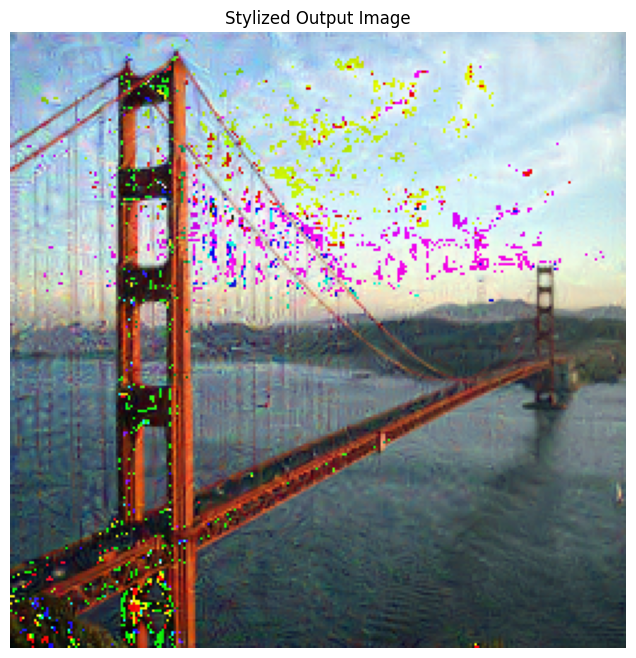

In [10]:
# ==========================================
# SHOW FINAL OUTPUT IMAGE
# ==========================================

output = input_img.cpu().detach().squeeze(0)

output = transforms.ToPILImage()(output)

plt.figure(figsize=(8,8))

plt.imshow(output)

plt.axis("off")

plt.title("Stylized Output Image")

plt.show()

In [11]:
# ==========================================
# SAVE OUTPUT IMAGE
# ==========================================

output.save("final_output.jpg")

print("Final Image Saved Successfully")

Final Image Saved Successfully
